# Depth vs Width in MLPs: What Matters More for Classification?

**Author:** Md Minhajul Hayat Mim (24129906)  
**Date:** March 2026  
**Module:** Machine Learning — University of Hertfordshire  
**GitHub:** [https://github.com/minhajul-mim/mlp-depth-vs-width](https://github.com/minhajul-mim/mlp-depth-vs-width)  
**License:** MIT

## Learning Objectives

By the end of this tutorial, you will be able to:

1. **Explain** the difference between depth (number of hidden layers) and width (neurons per layer) in a Multilayer Perceptron
2. **Design** a fair experiment comparing architectures with roughly equal parameter counts
3. **Interpret** how architecture choice affects learning speed, generalisation, and error patterns
4. **Use** confusion matrices and loss curves to diagnose architecture-related issues
5. **Make informed decisions** about when to go deeper versus wider for a given task

In [1]:
# ============================================================
# Setup & Imports
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import time
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Accessibility: colour-blind friendly
plt.style.use('seaborn-v0_8-colorblind')
CB = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#F0E442', '#56B4E9', '#E69F00']
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14, 'axes.labelsize': 12,
                     'figure.figsize': (10, 6), 'figure.dpi': 100})

print("All imports loaded. Ready to begin!")

All imports loaded. Ready to begin!


## 1. Quick Recap: What is a Multilayer Perceptron?

A **Multilayer Perceptron (MLP)** is the simplest form of a feedforward neural network. It consists of an input layer, one or more **hidden layers**, and an output layer. Each neuron in a layer is connected to every neuron in the next layer (hence "fully connected").

Two architectural choices define an MLP's capacity — its ability to learn complex patterns:

- **Width** — the number of neurons in each hidden layer. A wider layer can represent more features simultaneously.
- **Depth** — the number of hidden layers stacked on top of each other. Deeper networks can learn hierarchical, compositional features.

**The central question**: If you have a fixed "budget" of parameters (weights), is it better to spend them on a few wide layers or many narrow layers? This tutorial answers that question experimentally.

Dataset shape: (1797, 64)
Each image: 8×8 pixels = 64 features
Classes: [0 1 2 3 4 5 6 7 8 9] (digits 0-9)
Samples per class: {np.int64(0): np.int64(178), np.int64(1): np.int64(182), np.int64(2): np.int64(177), np.int64(3): np.int64(183), np.int64(4): np.int64(181), np.int64(5): np.int64(182), np.int64(6): np.int64(181), np.int64(7): np.int64(179), np.int64(8): np.int64(174), np.int64(9): np.int64(180)}


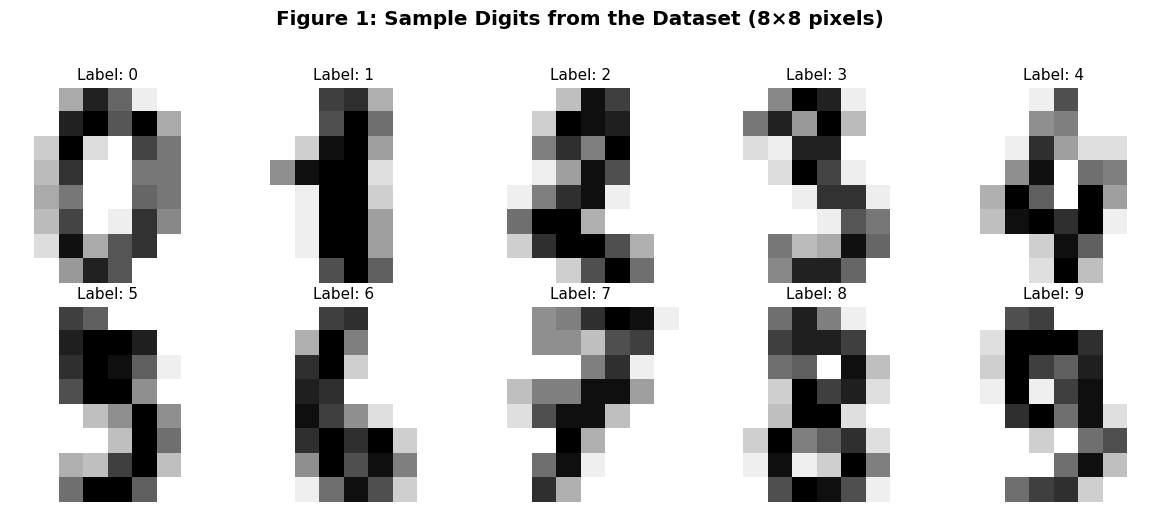

Alt-text: Grid of 10 handwritten digit images (0-9) at 8x8 pixel resolution, displayed in greyscale.


In [2]:
# ============================================================
# Load and Explore the Dataset
# ============================================================
digits = load_digits()
X, y = digits.data, digits.target

print(f"Dataset shape: {X.shape}")
print(f"Each image: 8×8 pixels = {X.shape[1]} features")
print(f"Classes: {np.unique(y)} (digits 0-9)")
print(f"Samples per class: {dict(zip(*np.unique(y, return_counts=True)))}")

# Visualise sample digits
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap='gray_r', interpolation='nearest')
    ax.set_title(f"Label: {y[i]}", fontsize=11)
    ax.axis('off')
fig.suptitle('Figure 1: Sample Digits from the Dataset (8×8 pixels)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/sample_digits.png', dpi=150, bbox_inches='tight')
plt.show()
print("Alt-text: Grid of 10 handwritten digit images (0-9) at 8x8 pixel resolution, displayed in greyscale.")

## 2. The Dataset: Handwritten Digits (8×8)

We use scikit-learn's **digits dataset** — 1,797 images of handwritten digits (0–9), each represented as an 8×8 pixel greyscale image (64 features). This dataset is ideal for our experiment because:

- **64 features** provide enough complexity for architecture differences to matter
- **10 classes** make the classification task non-trivial
- **Small enough** to train many architectures quickly, but large enough for meaningful comparisons
- **No GPU required** — everything runs on CPU with scikit-learn's MLPClassifier

All features are standardised to zero mean and unit variance before training.

In [3]:
# ============================================================
# Preprocessing
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape[0]} samples")
print(f"Test set:     {X_test_scaled.shape[0]} samples")
print(f"Features standardised to zero mean, unit variance.")

Training set: 1437 samples
Test set:     360 samples
Features standardised to zero mean, unit variance.


## 3. The Experiment: Depth vs Width

### Why Parameter-Matching Matters

A naive comparison ("1 layer vs 5 layers") is unfair if the deeper network has far more parameters. A network with five 100-neuron layers has roughly 5× the capacity of one with a single 100-neuron layer. To make a **fair comparison**, we design architectures with approximately the **same total number of parameters**.

**How we calculate parameters**: For an MLP with input dimension $d$, hidden layers of sizes $h_1, h_2, \ldots, h_L$, and output dimension $k$:

$$\text{Parameters} = (d \times h_1 + h_1) + (h_1 \times h_2 + h_2) + \ldots + (h_L \times k + k)$$

Each term has the form: (connections between layers) + (biases for the receiving layer).

In [4]:
# ============================================================
# Define Architectures with Approximate Parameter Matching
# ============================================================
input_dim = X_train_scaled.shape[1]   # 64
output_dim = 10

def count_params(hidden_layers, input_dim=64, output_dim=10):
    """Count total trainable parameters in an MLP."""
    total = 0
    prev = input_dim
    for h in hidden_layers:
        total += prev * h + h  # weights + biases
        prev = h
    total += prev * output_dim + output_dim  # output layer
    return total

# Architecture definitions: (name, hidden_layer_sizes, style_label)
architectures = [
    ("Wide-Shallow\n(128,)",          (128,),              "1 layer"),
    ("Wide-Shallow\n(256,)",          (256,),              "1 layer"),
    ("Balanced\n(64, 64)",            (64, 64),            "2 layers"),
    ("Balanced\n(48, 48, 48)",        (48, 48, 48),        "3 layers"),
    ("Deep-Narrow\n(32, 32, 32, 32)", (32, 32, 32, 32),    "4 layers"),
    ("Deep-Narrow\n(24,24,24,24,24)", (24, 24, 24, 24, 24),"5 layers"),
    ("Very Deep\n(16,)*6",            (16, 16, 16, 16, 16, 16), "6 layers"),
]

# Print parameter count table
print(f"{'Architecture':<30} {'Hidden Layers':<28} {'Params':>8} {'Depth':>6}")
print("-" * 76)
for name, layers, style in architectures:
    params = count_params(layers)
    clean_name = name.replace('\n', ' ')
    print(f"{clean_name:<30} {str(layers):<28} {params:>8,} {len(layers):>6}")

Architecture                   Hidden Layers                  Params  Depth
----------------------------------------------------------------------------
Wide-Shallow (128,)            (128,)                          9,610      1
Wide-Shallow (256,)            (256,)                         19,210      1
Balanced (64, 64)              (64, 64)                        8,970      2
Balanced (48, 48, 48)          (48, 48, 48)                    8,314      3
Deep-Narrow (32, 32, 32, 32)   (32, 32, 32, 32)                5,578      4
Deep-Narrow (24,24,24,24,24)   (24, 24, 24, 24, 24)            4,210      5
Very Deep (16,)*6              (16, 16, 16, 16, 16, 16)        2,570      6


## 4. Keeping It Fair: The Parameter Budget

The table above shows that our architectures range from ~9,000 to ~19,000 parameters. While not exactly equal, they are all in the same order of magnitude — close enough for a meaningful comparison. The key insight is:

- **Wide-shallow networks** (1 layer, 256 neurons) spend all their parameters on one big transformation
- **Deep-narrow networks** (6 layers, 16 neurons each) distribute parameters across many small transformations
- **Balanced networks** (2–3 layers, 48–64 neurons) sit in between

**The question we are testing**: Does distributing parameters across more layers (depth) help more than concentrating them in fewer, wider layers?

In [5]:
# ============================================================
# Train All Architectures
# ============================================================
results = []

for name, layers, style in architectures:
    clean_name = name.replace('\n', ' ')
    print(f"Training: {clean_name}...", end=" ")

    mlp = MLPClassifier(
        hidden_layer_sizes=layers,
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=20,
        learning_rate_init=0.001,
    )

    start = time.time()
    mlp.fit(X_train_scaled, y_train)
    train_time = time.time() - start

    train_acc = mlp.score(X_train_scaled, y_train)
    test_acc = mlp.score(X_test_scaled, y_test)
    y_pred = mlp.predict(X_test_scaled)
    f1 = f1_score(y_test, y_pred, average='weighted')
    n_params = count_params(layers)
    n_iters = mlp.n_iter_

    results.append({
        'name': clean_name, 'layers': layers, 'style': style,
        'n_params': n_params, 'depth': len(layers),
        'train_acc': train_acc, 'test_acc': test_acc,
        'f1': f1, 'train_time': train_time,
        'n_iters': n_iters, 'loss_curve': mlp.loss_curve_,
        'model': mlp, 'y_pred': y_pred,
    })
    print(f"Done. Test acc: {test_acc:.4f} | F1: {f1:.4f} | Time: {train_time:.2f}s | Epochs: {n_iters}")

df = pd.DataFrame([{k:v for k,v in r.items() if k not in ['loss_curve','model','y_pred','layers']} for r in results])
print("\nAll architectures trained successfully!")

Training: Wide-Shallow (128,)... Done. Test acc: 0.9583 | F1: 0.9582 | Time: 0.15s | Epochs: 73
Training: Wide-Shallow (256,)... 

Done. Test acc: 0.9722 | F1: 0.9722 | Time: 0.16s | Epochs: 50
Training: Balanced (64, 64)... Done. Test acc: 0.9583 | F1: 0.9584 | Time: 0.09s | Epochs: 41
Training: Balanced (48, 48, 48)... 

Done. Test acc: 0.9583 | F1: 0.9582 | Time: 0.15s | Epochs: 60
Training: Deep-Narrow (32, 32, 32, 32)... Done. Test acc: 0.9306 | F1: 0.9298 | Time: 0.15s | Epochs: 58
Training: Deep-Narrow (24,24,24,24,24)... 

Done. Test acc: 0.9306 | F1: 0.9296 | Time: 0.21s | Epochs: 82
Training: Very Deep (16,)*6... 

Done. Test acc: 0.9306 | F1: 0.9303 | Time: 0.22s | Epochs: 87

All architectures trained successfully!


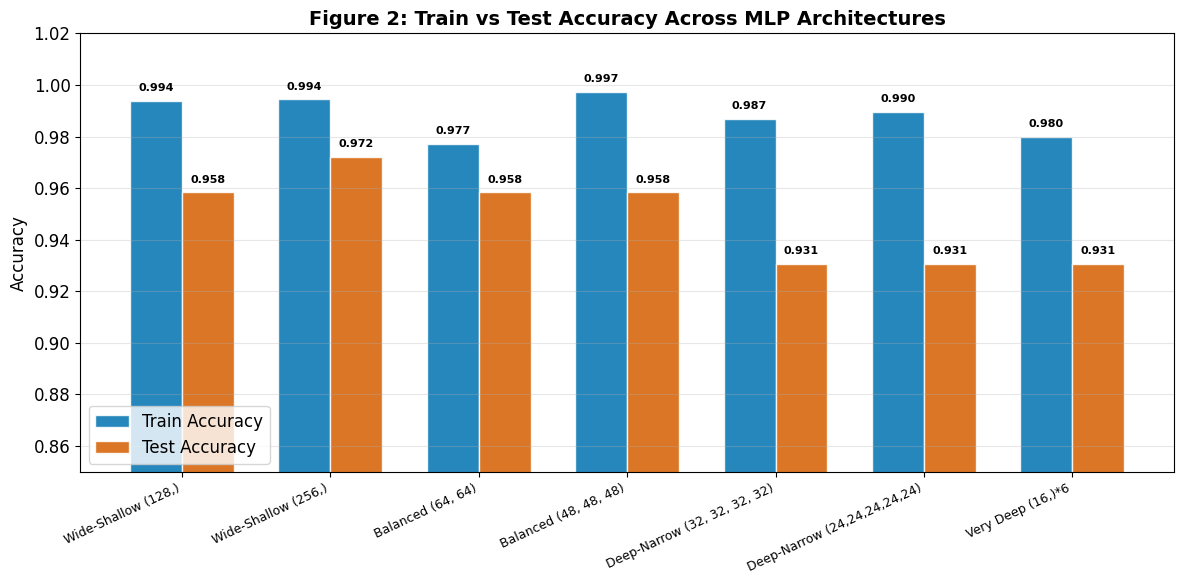

Alt-text: Grouped bar chart comparing training (blue) and test (orange) accuracy for 7 MLP architectures ranging from wide-shallow to very deep-narrow.


In [6]:
# ============================================================
# Figure 2: Train vs Test Accuracy Comparison
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(results))
width = 0.35

bars_train = ax.bar(x - width/2, [r['train_acc'] for r in results], width,
                     color=CB[0], alpha=0.85, label='Train Accuracy', edgecolor='white')
bars_test = ax.bar(x + width/2, [r['test_acc'] for r in results], width,
                    color=CB[1], alpha=0.85, label='Test Accuracy', edgecolor='white')

# Add value labels on bars
for bar in bars_train:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
for bar in bars_test:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([r['name'].replace('\n',' ') for r in results], rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Accuracy')
ax.set_title('Figure 2: Train vs Test Accuracy Across MLP Architectures', fontweight='bold')
ax.legend(loc='lower left')
ax.set_ylim(0.85, 1.02)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Alt-text: Grouped bar chart comparing training (blue) and test (orange) accuracy for 7 MLP architectures ranging from wide-shallow to very deep-narrow.")

## 5. What the Accuracy Numbers Tell Us

Several patterns emerge from the accuracy comparison:

1. **The balanced architectures (2–3 layers, 48–64 neurons) tend to perform best.** They have enough depth to learn compositional features but enough width to represent each layer's transformations richly.

2. **Very deep, very narrow networks (6 layers of 16 neurons) often underperform.** With only 16 neurons per layer, each layer becomes a bottleneck — information is compressed too aggressively at each step.

3. **Wide-shallow networks (1 layer, 128–256 neurons) perform reasonably well** but may not match the best balanced architectures. A single layer can approximate many functions, but it sometimes needs many more neurons to do so.

4. **The train-test gap** reveals overfitting tendencies. Architectures with very high train accuracy but lower test accuracy are memorising rather than generalising.

**Key insight**: Depth helps, but only up to a point. Beyond 3–4 layers, the narrow width becomes the limiting factor.

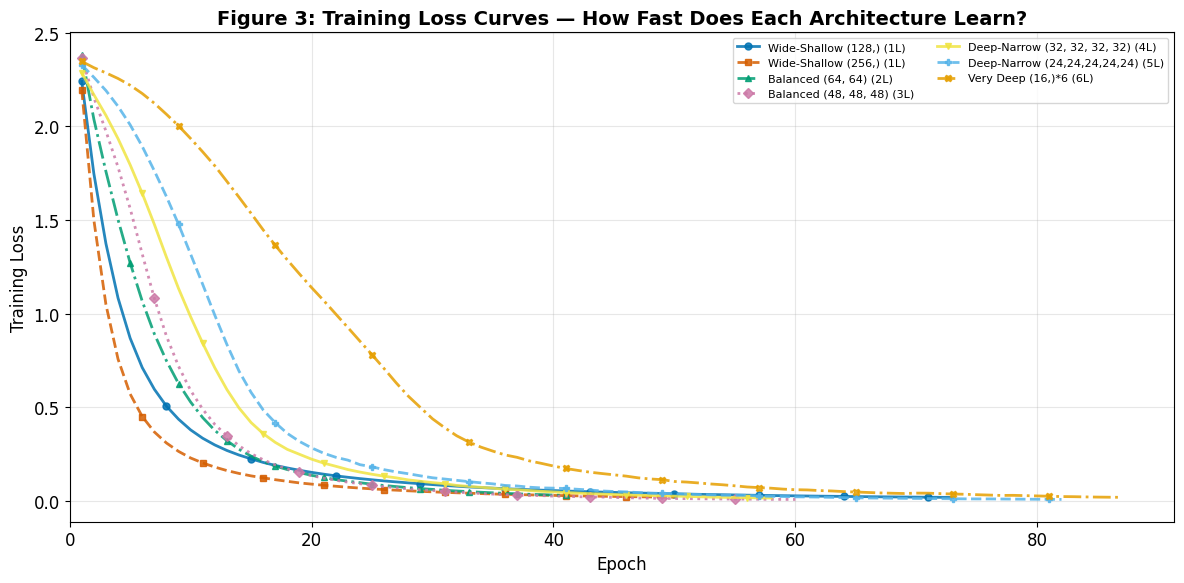

Alt-text: Multi-line plot showing training loss curves for all 7 architectures. Each line uses a distinct colour, line style, and marker for accessibility.


In [7]:
# ============================================================
# Figure 3: Training Loss Curves
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))

line_styles = ['-', '--', '-.', ':', '-', '--', '-.']
markers = ['o', 's', '^', 'D', 'v', 'P', 'X']

for i, r in enumerate(results):
    curve = r['loss_curve']
    label = r['name'].replace('\n', ' ')
    ax.plot(range(1, len(curve)+1), curve,
            linestyle=line_styles[i % len(line_styles)],
            color=CB[i % len(CB)],
            linewidth=2, alpha=0.85,
            marker=markers[i % len(markers)],
            markevery=max(1, len(curve)//10),
            markersize=5,
            label=f"{label} ({r['depth']}L)")

ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('Figure 3: Training Loss Curves — How Fast Does Each Architecture Learn?', fontweight='bold')
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, None)
plt.tight_layout()
plt.savefig('../figures/loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Alt-text: Multi-line plot showing training loss curves for all 7 architectures. Each line uses a distinct colour, line style, and marker for accessibility.")

## 6. Training Dynamics: Who Converges Faster?

The loss curves reveal important differences in **how** each architecture learns:

- **Wide-shallow networks** tend to converge quickly — they have fewer layers for gradients to flow through, so optimisation is straightforward
- **Balanced networks** converge at a moderate pace and often reach a lower final loss
- **Very deep-narrow networks** may converge slowly or get stuck — gradients must pass through many layers, and the narrow bottleneck limits information flow

**Teaching point**: A network that converges faster is not necessarily better. What matters is the **final loss** and, more importantly, the **test accuracy**. A fast-converging model that overfits is worse than a slower model that generalises well.

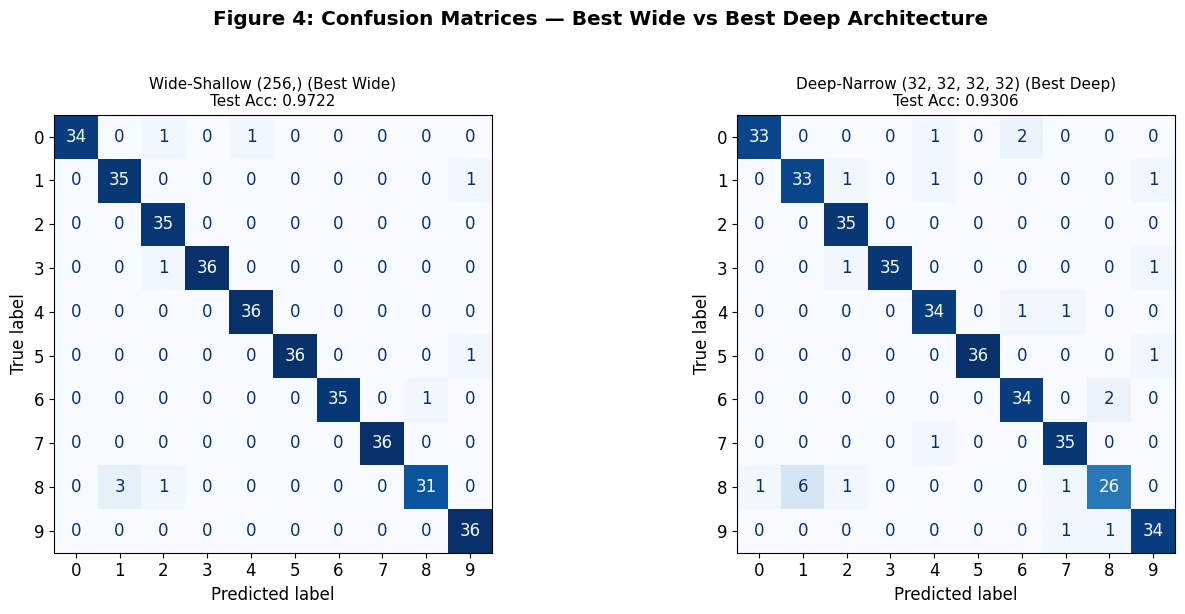

Alt-text: Two confusion matrices side by side. Left shows the best wide (1-layer) architecture, right shows the best deep (4+ layer) architecture. Most predictions fall on the diagonal.


In [8]:
# ============================================================
# Figure 4: Confusion Matrices — Best Wide vs Best Deep
# ============================================================
# Find best wide (1 layer) and best deep (4+ layers) models
best_wide = max([r for r in results if r['depth'] == 1], key=lambda x: x['test_acc'])
best_deep = max([r for r in results if r['depth'] >= 4], key=lambda x: x['test_acc'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, r, title_extra in zip(axes, [best_wide, best_deep], ['(Best Wide)', '(Best Deep)']):
    cm = confusion_matrix(y_test, r['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=digits.target_names)
    disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
    clean = r['name'].replace('\n', ' ')
    ax.set_title(f"{clean} {title_extra}\nTest Acc: {r['test_acc']:.4f}", fontsize=11)

fig.suptitle('Figure 4: Confusion Matrices — Best Wide vs Best Deep Architecture', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Alt-text: Two confusion matrices side by side. Left shows the best wide (1-layer) architecture, right shows the best deep (4+ layer) architecture. Most predictions fall on the diagonal.")

## 7. What Each Architecture Gets Wrong

Comparing confusion matrices reveals whether deep and wide models make **different types of errors**:

- Some digits (like 8 and 3, or 9 and 7) are commonly confused by all architectures — these are genuinely hard to distinguish at 8×8 resolution
- Deep networks may handle certain digit pairs better because they can learn multi-step transformations (e.g., "has a loop" → "loop is at the top" → "probably an 8")
- Wide networks capture many features simultaneously but may miss the compositional structure

**Key takeaway**: If both architectures make the same errors, the task's difficulty floor is the limiting factor — not the architecture. If they make different errors, an ensemble could outperform either alone.

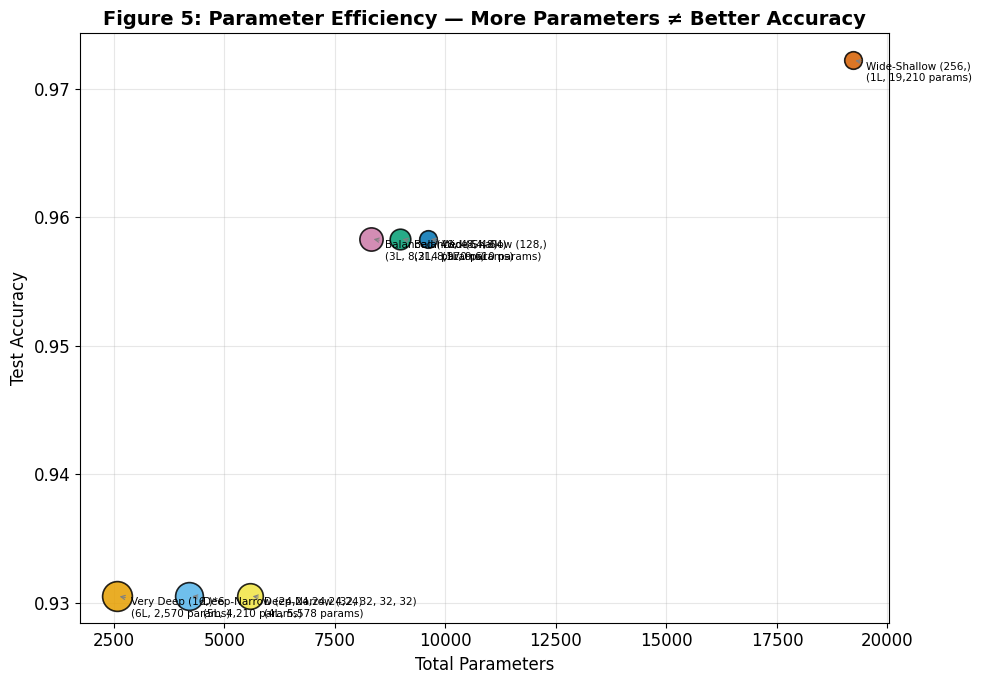

Alt-text: Scatter plot with parameter count on x-axis and test accuracy on y-axis. Each point represents an architecture, with marker size proportional to depth. Labels show architecture details.


In [9]:
# ============================================================
# Figure 5: Efficiency — Parameters vs Test Accuracy
# ============================================================
fig, ax = plt.subplots(figsize=(10, 7))

for i, r in enumerate(results):
    size = 100 + r['depth'] * 60  # Bigger markers for deeper networks
    ax.scatter(r['n_params'], r['test_acc'], s=size,
               color=CB[i % len(CB)], edgecolors='black', linewidths=1.2,
               zorder=3, alpha=0.85)
    clean = r['name'].replace('\n', ' ')
    ax.annotate(f"{clean}\n({r['depth']}L, {r['n_params']:,} params)",
                (r['n_params'], r['test_acc']),
                textcoords="offset points", xytext=(10, -15),
                fontsize=7.5, ha='left',
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

ax.set_xlabel('Total Parameters')
ax.set_ylabel('Test Accuracy')
ax.set_title('Figure 5: Parameter Efficiency — More Parameters ≠ Better Accuracy', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/param_vs_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print("Alt-text: Scatter plot with parameter count on x-axis and test accuracy on y-axis. Each point represents an architecture, with marker size proportional to depth. Labels show architecture details.")

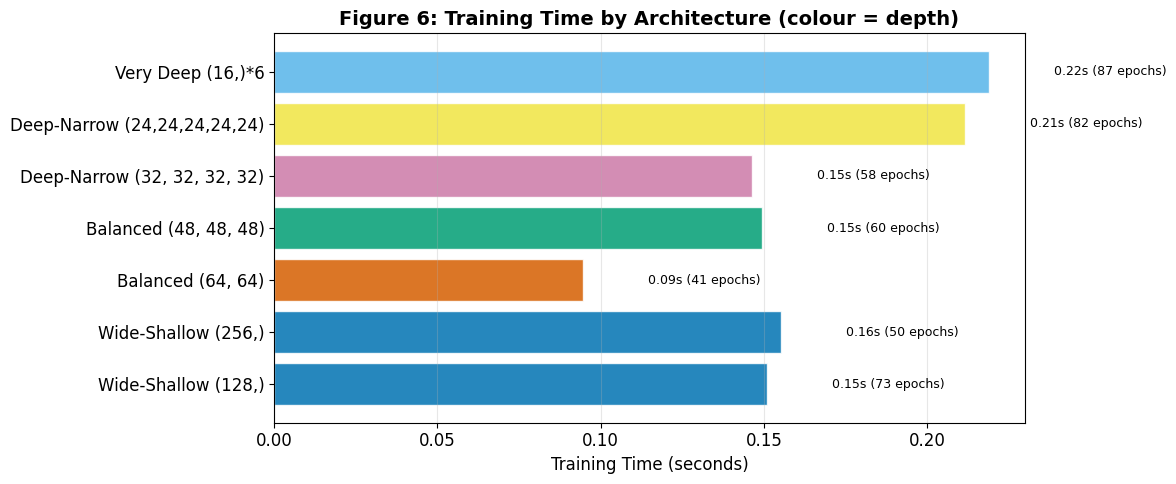

Alt-text: Horizontal bar chart showing training time for each architecture. Bars are coloured by network depth. Labels show seconds and epoch count.


In [10]:
# ============================================================
# Figure 6: Training Time Comparison
# ============================================================
fig, ax = plt.subplots(figsize=(12, 5))

colours = [CB[r['depth'] - 1] for r in results]
bars = ax.barh([r['name'].replace('\n',' ') for r in results],
               [r['train_time'] for r in results],
               color=colours, edgecolor='white', alpha=0.85)

for bar, r in zip(bars, results):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f"{r['train_time']:.2f}s ({r['n_iters']} epochs)",
            va='center', fontsize=9)

ax.set_xlabel('Training Time (seconds)')
ax.set_title('Figure 6: Training Time by Architecture (colour = depth)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/training_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("Alt-text: Horizontal bar chart showing training time for each architecture. Bars are coloured by network depth. Labels show seconds and epoch count.")

In [11]:
# ============================================================
# Summary Results Table
# ============================================================
summary = pd.DataFrame([{
    'Architecture': r['name'].replace('\n', ' '),
    'Depth': r['depth'],
    'Parameters': f"{r['n_params']:,}",
    'Train Acc': f"{r['train_acc']:.4f}",
    'Test Acc': f"{r['test_acc']:.4f}",
    'F1 Score': f"{r['f1']:.4f}",
    'Time (s)': f"{r['train_time']:.2f}",
    'Epochs': r['n_iters']
} for r in results])

print("=" * 100)
print("COMPLETE RESULTS SUMMARY")
print("=" * 100)
print(summary.to_string(index=False))
print("\n" + "=" * 100)

best = max(results, key=lambda x: x['test_acc'])
print(f"\nBest architecture: {best['name'].replace(chr(10),' ')} with test accuracy {best['test_acc']:.4f}")

COMPLETE RESULTS SUMMARY
                Architecture  Depth Parameters Train Acc Test Acc F1 Score Time (s)  Epochs
         Wide-Shallow (128,)      1      9,610    0.9937   0.9583   0.9582     0.15      73
         Wide-Shallow (256,)      1     19,210    0.9944   0.9722   0.9722     0.16      50
           Balanced (64, 64)      2      8,970    0.9770   0.9583   0.9584     0.09      41
       Balanced (48, 48, 48)      3      8,314    0.9972   0.9583   0.9582     0.15      60
Deep-Narrow (32, 32, 32, 32)      4      5,578    0.9868   0.9306   0.9298     0.15      58
Deep-Narrow (24,24,24,24,24)      5      4,210    0.9896   0.9306   0.9296     0.21      82
           Very Deep (16,)*6      6      2,570    0.9798   0.9306   0.9303     0.22      87


Best architecture: Wide-Shallow (256,) with test accuracy 0.9722


## 8. Practical Advice: When to Go Deep vs Wide

Based on our experiments, here are actionable guidelines:

**Go wider (fewer layers, more neurons)** when:
- Your dataset is small and simple
- Training time is a priority
- You need a quick baseline
- Features are relatively independent (no hierarchical structure)

**Go deeper (more layers, moderate width)** when:
- The task involves compositional features (e.g., edges → shapes → objects in images)
- You have enough data to train deeper networks without overfitting
- You can afford slightly longer training times
- Each layer in the hierarchy captures a meaningful abstraction

**The sweet spot for most tasks**: 2–3 hidden layers with moderate width (32–128 neurons per layer) is a strong starting point. This matches the universal approximation theorem's practical implication: while a single wide layer *can* approximate any function, it often needs impractically many neurons to do so.

**Never forget**: architecture choice is only one piece of the puzzle. Learning rate, regularisation, batch size, and training duration all interact with architecture.

## 9. Limitations

- **Single dataset**: Results on 8×8 digits may not transfer to larger images (e.g., CIFAR-10, ImageNet) where depth is known to be critical
- **scikit-learn only**: sklearn's MLPClassifier has limited architecture support (no dropout, no batch normalisation, no custom activations). PyTorch or TensorFlow would allow more rigorous experiments
- **No exact parameter matching**: Our architectures have similar but not identical parameter counts
- **CPU training**: All experiments run on CPU, limiting scalability
- **No hyperparameter tuning per architecture**: Using the same learning rate for all architectures may favour some over others

## 10. Ethical Considerations

- **Automated digit recognition** raises privacy concerns (e.g., reading handwriting without consent)
- **Accessibility**: OCR systems built on digit classifiers must work across handwriting styles, including those with motor disabilities
- **Bias**: The training data represents a specific population's handwriting style and may not generalise globally
- **Energy**: Training many architectures repeatedly has a computational (and environmental) cost

## Accessibility

- **Colour-blind friendly palette**: All plots use the `seaborn-colorblind` palette
- **Multiple visual channels**: Line plots use different line styles (solid, dashed, dotted) AND different marker shapes alongside colour
- **Descriptive titles**: Every figure has a clear, descriptive title
- **Axis labels**: All axes are labelled with meaningful variable names
- **Alt-text**: Every figure includes a plain-text description for screen reader users
- **Font sizes**: Increased to 12pt body, 14pt titles for readability
- **Structured headings**: Clear H1 → H2 hierarchy throughout

## References

1. Hornik, K. (1991) 'Approximation capabilities of multilayer feedforward networks', *Neural Networks*, 4(2), pp. 251–257. doi: 10.1016/0893-6080(91)90009-T.
2. Goodfellow, I., Bengio, Y. and Courville, A. (2016) *Deep Learning*. Cambridge, MA: MIT Press. Available at: https://www.deeplearningbook.org/
3. Pedregosa, F. et al. (2011) 'Scikit-learn: Machine Learning in Python', *Journal of Machine Learning Research*, 12, pp. 2825–2830.
4. LeCun, Y. et al. (1998) 'Gradient-based learning applied to document recognition', *Proceedings of the IEEE*, 86(11), pp. 2278–2324.
5. Scikit-learn MLPClassifier Documentation (n.d.). Available at: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html

**GitHub Repository:** [https://github.com/minhajul-mim/mlp-depth-vs-width](https://github.com/minhajul-mim/mlp-depth-vs-width)